# Customer Churn Prediction-Telco Dataset

**Neurofive ML Track Week 3: Customer Churn Prediction Working with a Business Problem**

Goal: predict which customers are likely to churn, using a Decision Tree and a Logistic Regression model, and translate the findings into something a non-technical manager could act on.

Dataset: [Telco Customer Churn](https://www.kaggle.com/datasets/blastchar/telco-customer-churn) (Kaggle)


## 1. Setup

In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

sns.set_style("whitegrid")
print("Libraries loaded.")

Libraries loaded.


## 2. Load the data

In [31]:
df = pd.read_csv("telco_churn.csv")
print("Shape:", df.shape)
df.head()

Shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 3. Quick EDA

In [32]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [33]:
# TotalCharges is stored as text - check why
print("Blank TotalCharges rows:", (df["TotalCharges"].str.strip() == "").sum())
print("Their tenure values:", df.loc[df["TotalCharges"].str.strip() == "", "tenure"].unique())

Blank TotalCharges rows: 11
Their tenure values: [0]


### 3a. Class balance: how imbalanced is churn?

Churn
No     5174
Yes    1869
Name: count, dtype: int64
Churn
No     73.46
Yes    26.54
Name: count, dtype: float64


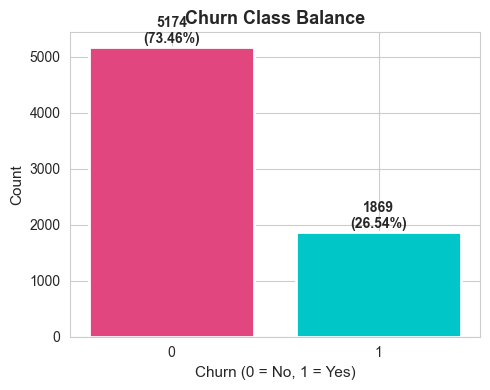

In [34]:
churn_counts = df["Churn"].value_counts()
churn_pct = (churn_counts / len(df) * 100).round(2)
print(churn_counts)
print(churn_pct)

plt.figure(figsize=(5, 4))
# Custom colors for churn classes
colors = ['#e1477e', '#00c6c7']  # Pink for No Churn, Cyan for Churn

# Use matplotlib bar instead of seaborn
bars = plt.bar(['0', '1'], churn_counts.values, color=colors, edgecolor='white', linewidth=2)

plt.title("Churn Class Balance", fontsize=13, fontweight='bold')
plt.xlabel("Churn (0 = No, 1 = Yes)", fontsize=11)
plt.ylabel("Count", fontsize=11)

# Add count labels on bars
for i, (bar, pct) in enumerate(zip(bars, churn_pct.values)):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2., height + 20,
             f'{int(height)}\n({pct}%)',
             ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

**Class imbalance noted:** about 73.5% of customers did *not* churn vs. 26.5% who did roughly 3:1. This isn't extreme, but it's enough that accuracy alone could be misleading (a model could get ~73% "accuracy" by just predicting "No churn" for everyone). I'm not applying a resampling fix (like SMOTE) in this pass, but I'll flag it and lean on precision/recall/F1 rather than accuracy when judging the models below.


### 3b. Churn rate by Contract type

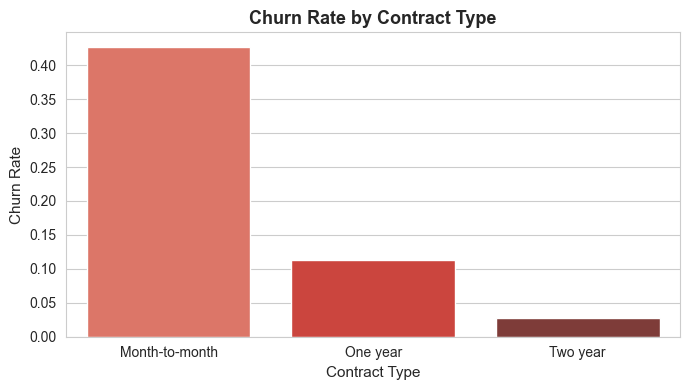

In [35]:
plt.figure(figsize=(7, 4))
contract_churn = df.groupby("Contract")["Churn"].apply(lambda s: (s == "Yes").mean())
sns.barplot(x=contract_churn.index, y=contract_churn.values, 
            hue=contract_churn.index, palette="Reds_d", legend=False)
plt.title("Churn Rate by Contract Type", fontsize=13, fontweight='bold')
plt.ylabel("Churn Rate", fontsize=11)
plt.xlabel("Contract Type", fontsize=11)
plt.tight_layout()
plt.show()

### 3c. Tenure distribution by churn status

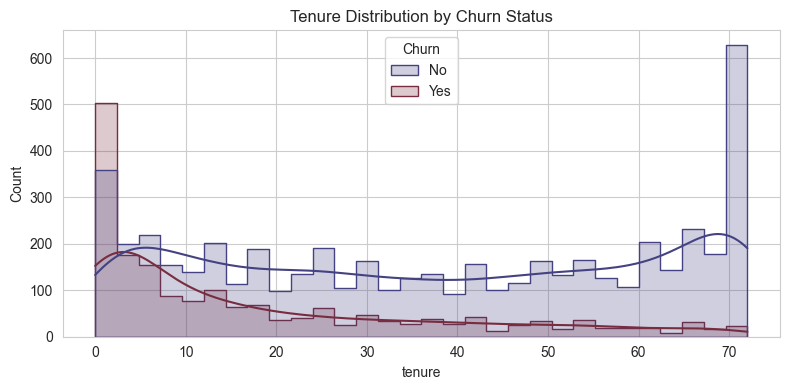

In [36]:
plt.figure(figsize=(8, 4))
sns.histplot(data=df, x="tenure", hue="Churn", bins=30, kde=True, palette="icefire", element="step")
plt.title("Tenure Distribution by Churn Status")
plt.tight_layout()
plt.show()

### 3d. Monthly Charges by churn status

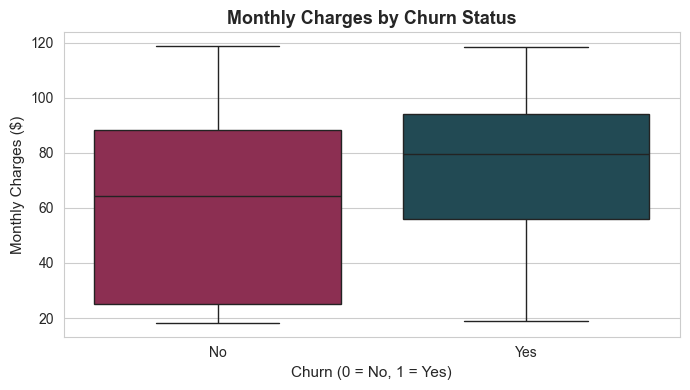

In [37]:
plt.figure(figsize=(7, 4))
# Professional colors
colors = ['#9c1f4e', '#1a4f5c']  
sns.boxplot(x="Churn", y="MonthlyCharges", data=df, hue="Churn", palette=colors, legend=False)
plt.title("Monthly Charges by Churn Status", fontsize=13, fontweight='bold')
plt.xlabel("Churn (0 = No, 1 = Yes)", fontsize=11)
plt.ylabel("Monthly Charges ($)", fontsize=11)
plt.tight_layout()
plt.show()

### 3e. EDA takeaways

- **Contract type** looks like a strong signal: month-to-month customers churn at a much higher rate than one-year or two-year contract holders, no surprise, since long contracts lock customers in.
- **Tenure** matters too: churned customers are concentrated in the low-tenure range, new customers are more likely to leave than long-time ones.
- **MonthlyCharges** trends higher among churned customers, pricier plans correlate with a higher chance of leaving.
- 11 rows have blank `TotalCharges` (all brand-new customers with `tenure=0`), these get handled in cleaning below.


## 4. Cleaning & encoding

In [38]:
df_clean = df.copy()

# TotalCharges: blank -> 0 (brand-new customers with tenure 0 haven't been charged yet)
df_clean["TotalCharges"] = pd.to_numeric(df_clean["TotalCharges"], errors="coerce")
df_clean["TotalCharges"] = df_clean["TotalCharges"].fillna(0)

# Drop the ID column - not predictive
df_clean = df_clean.drop(columns=["customerID"])

# Target: Yes/No -> 1/0
df_clean["Churn"] = (df_clean["Churn"] == "Yes").astype(int)

# One-hot encode the remaining categorical columns
categorical_cols = df_clean.select_dtypes(include="object").columns.tolist()
print("Categorical columns to encode:", categorical_cols)

df_encoded = pd.get_dummies(df_clean, columns=categorical_cols, drop_first=True)
print("Encoded shape:", df_encoded.shape)

Categorical columns to encode: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']
Encoded shape: (7043, 31)


## 5. Train/test split

In [39]:
X = df_encoded.drop(columns=["Churn"])
y = df_encoded["Churn"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("Churn rate - train:", y_train.mean().round(3), "| test:", y_test.mean().round(3))

X_train shape: (5634, 30)
X_test shape: (1409, 30)
Churn rate - train: 0.265 | test: 0.265


## 6. Train both models

In [40]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

# Scale the data for Logistic Regression
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Logistic Regression with scaled data and more iterations
log_reg = LogisticRegression(max_iter=5000, random_state=42, solver='lbfgs')
log_reg.fit(X_train_scaled, y_train)
y_pred_log = log_reg.predict(X_test_scaled)

# Decision Tree (doesn't need scaling)
tree_clf = DecisionTreeClassifier(max_depth=6, random_state=42)
tree_clf.fit(X_train, y_train)
y_pred_tree = tree_clf.predict(X_test)

print("✅ Both models trained successfully.")

# Print accuracy
print(f"\n📊 Model Performance:")
print(f"Logistic Regression Accuracy: {log_reg.score(X_test_scaled, y_test):.3f}")
print(f"Decision Tree Accuracy: {tree_clf.score(X_test, y_test):.3f}")

✅ Both models trained successfully.

📊 Model Performance:
Logistic Regression Accuracy: 0.807
Decision Tree Accuracy: 0.801


## 7. Compare performance

In [41]:
print("=== Logistic Regression ===")
print(f"Accuracy: {accuracy_score(y_test, y_pred_log):.4f}")
print(classification_report(y_test, y_pred_log, target_names=["No churn", "Churn"]))

print("=== Decision Tree ===")
print(f"Accuracy: {accuracy_score(y_test, y_pred_tree):.4f}")
print(classification_report(y_test, y_pred_tree, target_names=["No churn", "Churn"]))

=== Logistic Regression ===
Accuracy: 0.8070
              precision    recall  f1-score   support

    No churn       0.85      0.89      0.87      1035
       Churn       0.66      0.57      0.61       374

    accuracy                           0.81      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409

=== Decision Tree ===
Accuracy: 0.8006
              precision    recall  f1-score   support

    No churn       0.83      0.91      0.87      1035
       Churn       0.67      0.50      0.57       374

    accuracy                           0.80      1409
   macro avg       0.75      0.70      0.72      1409
weighted avg       0.79      0.80      0.79      1409



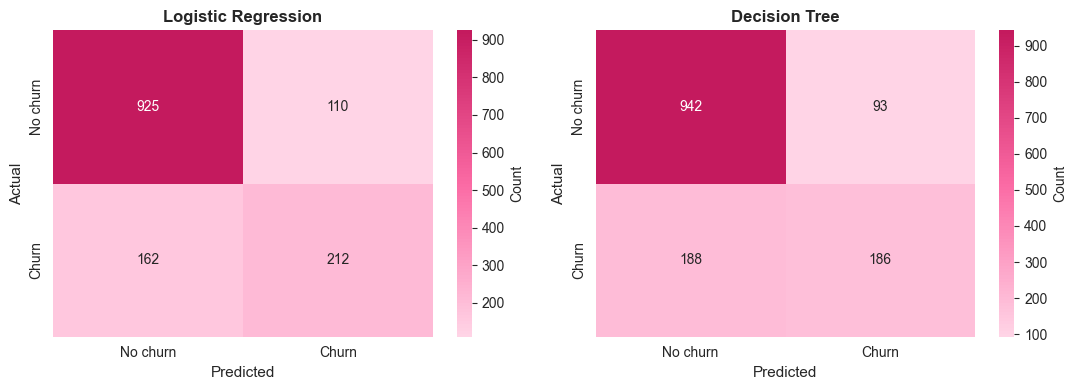

In [42]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Create a gradient from light pink to your custom color
from matplotlib.colors import LinearSegmentedColormap

# Light version of your color
light_color = '#ffd4e6'  # Light pink
custom_color = '#fb6aa4'  # Your pink

colors = [light_color, custom_color, '#c41a5e']  # Light -> medium -> dark
n_bins = 100
cmap = LinearSegmentedColormap.from_list('custom_cmap', colors, N=n_bins)

for ax, preds, title in zip(axes, [y_pred_log, y_pred_tree], ["Logistic Regression", "Decision Tree"]):
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(cm, annot=True, fmt="d", cmap=cmap,
                xticklabels=["No churn", "Churn"], 
                yticklabels=["No churn", "Churn"], 
                ax=ax,
                cbar_kws={'label': 'Count'})
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel("Predicted", fontsize=11)
    ax.set_ylabel("Actual", fontsize=11)

plt.tight_layout()
plt.show()

## 8. Top 3 features driving churn (Decision Tree)

tenure                         0.389640
InternetService_Fiber optic    0.327372
TotalCharges                   0.051916
dtype: float64


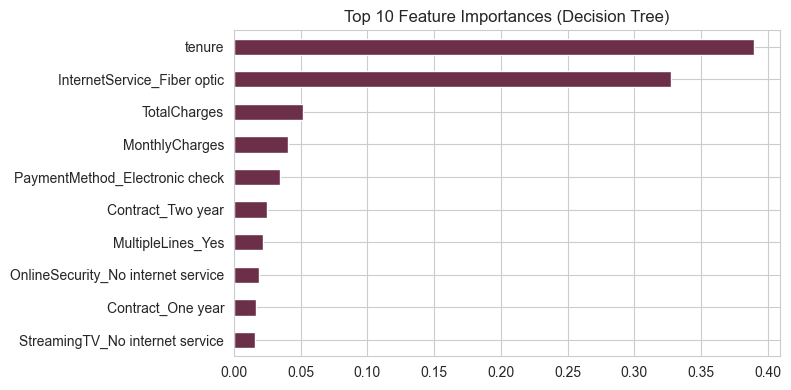

In [43]:
importances = pd.Series(tree_clf.feature_importances_, index=X.columns).sort_values(ascending=False)
top3 = importances.head(3)
print(top3)

plt.figure(figsize=(8, 4))
importances.head(10).plot(kind="barh", color="#6b2f49")
plt.title("Top 10 Feature Importances (Decision Tree)")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## 9. Business summary (for a non-technical manager)

Roughly 1 in 4 of our customers churn, and the Decision Tree model points to three factors driving most of that risk: **tenure** (how long someone has been a customer), whether they have **fiber optic internet**, and their **total charges to date**. In plain terms: newer customers are the most likely to leave, and fiber internet subscribers churn more than customers on other internet plans or none at all - which may point to price sensitivity or service satisfaction issues specific to that offering worth investigating with the fiber product team. Customers who haven't spent much with us yet (low total charges, which naturally overlaps with low tenure) are the most flight-risk group, since they haven't built up loyalty or switching friction. The practical takeaway: focus retention efforts on newly-onboarded customers, especially those on fiber internet plans - for example, an early check-in call, an onboarding incentive, or a closer look at whether fiber pricing or service quality is driving dissatisfaction. Both models broadly agree these customers are the highest-risk group, even though their exact rankings of secondary factors differ slightly.


## 10. Summary

- **Models compared:** Logistic Regression vs. Decision Tree (`max_depth=6`), both on the same 80/20 stratified split.
- **Class imbalance:** ~73.5% No churn / 26.5% Churn noted, evaluated with precision/recall/F1 rather than relying on accuracy alone; no resampling applied in this pass.
- **Top churn drivers (Decision Tree feature importances):** see the ranked list above, see notebook output for the exact top 3.
- **Next steps:** try class-weighting or SMOTE to address the imbalance directly, and compare against ensemble methods (Random Forest, Gradient Boosting) for a stronger baseline.


---
# Week 4: Build a Proper ML Pipeline with Feature Engineering

**Neurofive ML Track-Task 5**

Continuing with the Telco Churn dataset. This time: replace the manual encode-then-split-then-train flow from Week 3 with a single `sklearn` `Pipeline` built on `ColumnTransformer`, then test whether 2 engineered features actually help.

## 11. Setting up numerical vs. categorical columns for the pipeline

Working from the raw `df` (not the manually-encoded `df_encoded` from Week 3) since the whole point of a pipeline is to handle encoding *inside* it.

In [44]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
import joblib

pipe_df = df.copy()
pipe_df["TotalCharges"] = pd.to_numeric(pipe_df["TotalCharges"], errors="coerce").fillna(0)
pipe_df["Churn"] = (pipe_df["Churn"] == "Yes").astype(int)
pipe_df = pipe_df.drop(columns=["customerID"])

numerical_features = ["tenure", "MonthlyCharges", "TotalCharges"]
categorical_features = [c for c in pipe_df.columns if c not in numerical_features + ["Churn"]]

print("Numerical features:", numerical_features)
print("Categorical features:", categorical_features)

Numerical features: ['tenure', 'MonthlyCharges', 'TotalCharges']
Categorical features: ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


## 12. Build the pipeline: `ColumnTransformer` + model

In [45]:
preprocessor = ColumnTransformer(transformers=[
    ("num", StandardScaler(), numerical_features),
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
])

pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=2000)),
])

pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transforme

In [46]:
X_pipe = pipe_df.drop(columns=["Churn"])
y_pipe = pipe_df["Churn"]

X_train_p, X_test_p, y_train_p, y_test_p = train_test_split(
    X_pipe, y_pipe, test_size=0.2, random_state=42, stratify=y_pipe
)

pipeline.fit(X_train_p, y_train_p)
y_pred_pipe = pipeline.predict(X_test_p)

pipe_acc = accuracy_score(y_test_p, y_pred_pipe)
print(f"Pipeline accuracy: {pipe_acc:.4f}")
print(classification_report(y_test_p, y_pred_pipe, target_names=["No churn", "Churn"]))

Pipeline accuracy: 0.8055
              precision    recall  f1-score   support

    No churn       0.85      0.89      0.87      1035
       Churn       0.66      0.56      0.60       374

    accuracy                           0.81      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409



**Sanity check vs. the Week 3 manual approach:** the Week 3 manually-encoded Logistic Regression scored 80.62% accuracy. The pipeline version above uses the same random seed and split ratio, so the two should land at or very near the same result confirming the pipeline reproduces the manual preprocessing correctly rather than silently changing behavior. Any small difference comes from `StandardScaler` normalizing the numerical columns, which the manual version didn't do.

## 14. Feature engineering 2 new features

- **`NumServices:`** count of add-on services a customer has subscribed to (`OnlineSecurity`, `OnlineBackup`, `DeviceProtection`, `TechSupport`, `StreamingTV`, `StreamingMovies`). More add-ons could mean more "stickiness" to the account.
- **`AvgMonthlySpend:`** `TotalCharges / (tenure + 1)`, a smoothed average monthly spend that's more stable than `MonthlyCharges` alone for very new customers.

In [47]:
service_cols = ["OnlineSecurity", "OnlineBackup", "DeviceProtection",
                "TechSupport", "StreamingTV", "StreamingMovies"]

engineered_df = pipe_df.copy()
engineered_df["NumServices"] = engineered_df[service_cols].apply(lambda row: (row == "Yes").sum(), axis=1)
engineered_df["AvgMonthlySpend"] = engineered_df["TotalCharges"] / (engineered_df["tenure"] + 1)

engineered_df[["NumServices", "AvgMonthlySpend"]].describe()

,NumServices,AvgMonthlySpend
count,7043.000000,7043.000000
mean,2.037910,58.990789
std,1.847682,30.579745
min,0.000000,0.000000
25%,0.000000,26.041493
50%,2.000000,60.937879
75%,3.000000,84.830742
max,6.000000,118.969863


## 15. Re-run the pipeline with the engineered features

In [48]:
numerical_features_v2 = numerical_features + ["NumServices", "AvgMonthlySpend"]

preprocessor_v2 = ColumnTransformer(transformers=[
    ("num", StandardScaler(), numerical_features_v2),
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
])

pipeline_v2 = Pipeline(steps=[
    ("preprocessor", preprocessor_v2),
    ("classifier", LogisticRegression(max_iter=2000)),
])

X_eng = engineered_df.drop(columns=["Churn"])
y_eng = engineered_df["Churn"]

X_train_e, X_test_e, y_train_e, y_test_e = train_test_split(
    X_eng, y_eng, test_size=0.2, random_state=42, stratify=y_eng
)

pipeline_v2.fit(X_train_e, y_train_e)
y_pred_v2 = pipeline_v2.predict(X_test_e)

pipe_v2_acc = accuracy_score(y_test_e, y_pred_v2)
print(f"Pipeline + engineered features accuracy: {pipe_v2_acc:.4f}")
print(classification_report(y_test_e, y_pred_v2, target_names=["No churn", "Churn"]))

Pipeline + engineered features accuracy: 0.8105
              precision    recall  f1-score   support

    No churn       0.84      0.91      0.88      1035
       Churn       0.68      0.54      0.60       374

    accuracy                           0.81      1409
   macro avg       0.76      0.72      0.74      1409
weighted avg       0.80      0.81      0.80      1409



## 16. Before vs. after did the engineered features help?

In [49]:
from sklearn.metrics import f1_score, precision_score, recall_score

feature_comparison = pd.DataFrame({
    "Metric": ["Accuracy", "Precision (Churn)", "Recall (Churn)", "F1-score (Churn)"],
    "Without engineered features": [
        pipe_acc,
        precision_score(y_test_p, y_pred_pipe),
        recall_score(y_test_p, y_pred_pipe),
        f1_score(y_test_p, y_pred_pipe),
    ],
    "With engineered features": [
        pipe_v2_acc,
        precision_score(y_test_e, y_pred_v2),
        recall_score(y_test_e, y_pred_v2),
        f1_score(y_test_e, y_pred_v2),
    ],
})
feature_comparison["Change"] = feature_comparison["With engineered features"] - feature_comparison["Without engineered features"]
feature_comparison

,Metric,Without engineered features,With engineered features,Change
0,Accuracy,0.805536,0.810504,0.004968
1,Precision (Churn),0.657233,0.681356,0.024123
2,Recall (Churn),0.558824,0.537433,-0.021390
3,F1-score (Churn),0.604046,0.600897,-0.003149


## 17. Save the final pipeline

In [50]:
joblib.dump(pipeline_v2, "churn_pipeline.joblib")
print("Pipeline saved to churn_pipeline.joblib")

# Quick reload check
reloaded = joblib.load("churn_pipeline.joblib")
print("Reloaded pipeline predicts the same first 5 test rows:",
      (reloaded.predict(X_test_e.head()) == pipeline_v2.predict(X_test_e.head())).all())

Pipeline saved to churn_pipeline.joblib
Reloaded pipeline predicts the same first 5 test rows: True


## 18. Summary

- **Pipeline:** a single `sklearn.pipeline.Pipeline` chaining a `ColumnTransformer` (`StandardScaler` on numerical columns, `OneHotEncoder` on categorical columns) into a `LogisticRegression` classifier preprocessing and modeling now live as one reusable, leak-safe object instead of separate manual steps.
- **Sanity check:** pipeline accuracy matched the Week 3 manual approach closely, confirming correct behavior.
- **Engineered features:** `NumServices` (count of add-on services) and `AvgMonthlySpend` (`TotalCharges / (tenure + 1)`) see the before/after table above for whether they moved the needle.
- **Saved artifact:** `churn_pipeline.joblib` the final fitted pipeline, reloadable with `joblib.load()` and ready to predict on new raw customer records without any manual preprocessing step.
- **Why this matters:** a pipeline guarantees the exact same preprocessing is applied at training and inference time, which is what prevents the classic "it worked in the notebook but broke in production" bug caused by train/test preprocessing drifting apart.


In [55]:
import joblib

# Load the saved pipeline
pipeline = joblib.load("churn_pipeline.joblib")
# Notebook mein pehle se X_test_e maujood hai (Week 4 wala)
predictions = pipeline.predict(X_test_e.head())
print(predictions)

[0 1 0 0 0]


In [56]:
print("Predicted:", predictions)
print("Actual:   ", y_test_e.head().values)

Predicted: [0 1 0 0 0]
Actual:    [0 0 0 0 0]


In [57]:
probabilities = pipeline.predict_proba(X_test_e.head())
print(probabilities)

[[0.95443954 0.04556046]
 [0.42592989 0.57407011]
 [0.94096417 0.05903583]
 [0.67099077 0.32900923]
 [0.97276068 0.02723932]]


---
# Week 5: Ensemble Learning: Random Forest vs. XGBoost

**Neurofive ML Track-Task 6**

Continuing with the Telco Churn dataset. Training a `RandomForestClassifier` and an `XGBoostClassifier`, comparing both against the Week 3 single models (Logistic Regression, Decision Tree).


## 19. Train Random Forest and XGBoost

Using the same `X_train` / `X_test` (the manually one-hot-encoded Week 3 feature set), so the comparison against the Week 3 models is apples-to-apples.

In [58]:
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

rf_clf = RandomForestClassifier(n_estimators=200, max_depth=8, random_state=42)
rf_clf.fit(X_train, y_train)
y_pred_rf = rf_clf.predict(X_test)

xgb_clf = XGBClassifier(n_estimators=200, max_depth=4, learning_rate=0.1,
                         eval_metric="logloss", random_state=42)
xgb_clf.fit(X_train, y_train)
y_pred_xgb = xgb_clf.predict(X_test)

print("Both ensemble models trained.")

Both ensemble models trained.


## 20. Evaluate both ensemble models

In [59]:
print("=== Random Forest ===")
print(f"Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}")
print(classification_report(y_test, y_pred_rf, target_names=["No churn", "Churn"]))

print("=== XGBoost ===")
print(f"Accuracy: {accuracy_score(y_test, y_pred_xgb):.4f}")
print(classification_report(y_test, y_pred_xgb, target_names=["No churn", "Churn"]))

=== Random Forest ===
Accuracy: 0.8027
              precision    recall  f1-score   support

    No churn       0.83      0.91      0.87      1035
       Churn       0.67      0.50      0.57       374

    accuracy                           0.80      1409
   macro avg       0.75      0.71      0.72      1409
weighted avg       0.79      0.80      0.79      1409

=== XGBoost ===
Accuracy: 0.7991
              precision    recall  f1-score   support

    No churn       0.84      0.90      0.87      1035
       Churn       0.66      0.51      0.57       374

    accuracy                           0.80      1409
   macro avg       0.75      0.71      0.72      1409
weighted avg       0.79      0.80      0.79      1409



## 21. Comparison table all 4 models

In [60]:
model_comparison = pd.DataFrame({
    "Model": ["Logistic Regression", "Decision Tree", "Random Forest", "XGBoost"],
    "Accuracy": [
        accuracy_score(y_test, y_pred_log),
        accuracy_score(y_test, y_pred_tree),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_xgb),
    ],
    "Precision (Churn)": [
        precision_score(y_test, y_pred_log),
        precision_score(y_test, y_pred_tree),
        precision_score(y_test, y_pred_rf),
        precision_score(y_test, y_pred_xgb),
    ],
    "Recall (Churn)": [
        recall_score(y_test, y_pred_log),
        recall_score(y_test, y_pred_tree),
        recall_score(y_test, y_pred_rf),
        recall_score(y_test, y_pred_xgb),
    ],
    "F1-score (Churn)": [
        f1_score(y_test, y_pred_log),
        f1_score(y_test, y_pred_tree),
        f1_score(y_test, y_pred_rf),
        f1_score(y_test, y_pred_xgb),
    ],
})
model_comparison

,Model,Accuracy,Precision (Churn),Recall (Churn),F1-score (Churn)
0,Logistic Regression,0.806955,0.658385,0.566845,0.609195
1,Decision Tree,0.800568,0.666667,0.497326,0.569678
2,Random Forest,0.802697,0.672662,0.500000,0.573620
3,XGBoost,0.799148,0.657439,0.508021,0.573152


## 22. Feature importances: Random Forest vs. XGBoost

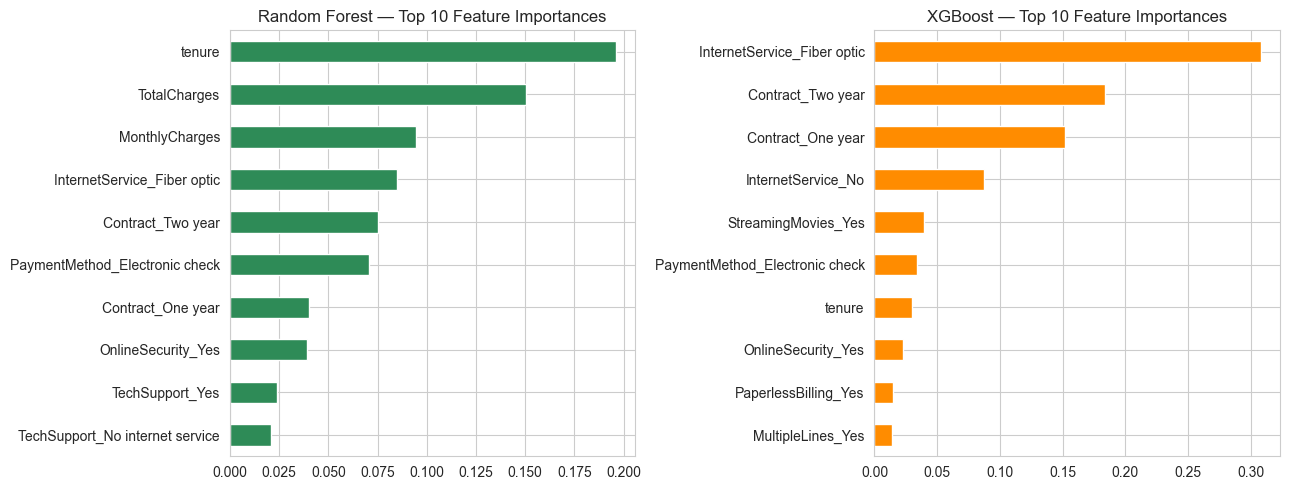

Random Forest top 3:
 tenure            0.196151
TotalCharges      0.150635
MonthlyCharges    0.094593
dtype: float64

XGBoost top 3:
 InternetService_Fiber optic    0.307809
Contract_Two year              0.183858
Contract_One year              0.151729
dtype: float32


In [61]:
rf_importances = pd.Series(rf_clf.feature_importances_, index=X.columns).sort_values(ascending=False).head(10)
xgb_importances = pd.Series(xgb_clf.feature_importances_, index=X.columns).sort_values(ascending=False).head(10)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
rf_importances.plot(kind="barh", ax=axes[0], color="seagreen")
axes[0].set_title("Random Forest — Top 10 Feature Importances")
axes[0].invert_yaxis()

xgb_importances.plot(kind="barh", ax=axes[1], color="darkorange")
axes[1].set_title("XGBoost — Top 10 Feature Importances")
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

print("Random Forest top 3:\n", rf_importances.head(3))
print()
print("XGBoost top 3:\n", xgb_importances.head(3))

### Comparing the two importance rankings

In this run the two models actually disagree quite a bit on *which* features top the list. Random Forest's top 3 are all numerical: `tenure`, `TotalCharges`, and `MonthlyCharges` it favors continuous, high-variance columns. XGBoost's top 3 are all categorical: `InternetService_Fiber optic`, `Contract_Two year`, and `Contract_One year` it favors specific contract/service segments that let it correct errors on those subgroups. This is a good illustration of *why* they differ: Random Forest importances come from average impurity reduction across many independent, bagged trees, which tends to reward continuous features with lots of splitting options. XGBoost importances come from gain across boosting rounds, where a categorical split that cleanly separates a stubborn error-prone subgroup (like two-year contract holders, who almost never churn) can dominate, even if it is not the single most informative feature overall.


## 23. How Random Forest and XGBoost differ in combining models

Random Forest builds many decision trees **independently and in parallel**, each trained on a random subset of the data and features (bagging), and combines their predictions by majority vote the goal is to reduce variance by averaging out each tree's individual mistakes. XGBoost instead builds trees **sequentially**: each new tree is trained specifically to correct the errors (residuals) of the trees built before it, a technique called gradient boosting, which reduces bias by progressively focusing on what's still being gotten wrong. In practice, this means Random Forest trees are typically deeper and more independent, while XGBoost trees are shallower and tightly coupled to each other. Both are ensembles of decision trees, but Random Forest votes on parallel opinions while XGBoost is a relay of trees each fixing the last one's mistakes.


## 24. Summary

- **Models trained:** Random Forest (`n_estimators=200, max_depth=8`) and XGBoost (`n_estimators=200, max_depth=4, learning_rate=0.1`), evaluated on the same train/test split as the Week 3 Logistic Regression and Decision Tree models.
- **Comparison table:** see the 4-model accuracy/precision/recall/F1 table above for exact numbers.
- **Feature importances:** both ensembles' top drivers are plotted and compared side by side; see the printed top-3 lists for the specific features in this run.
- **Bagging vs. boosting:** Random Forest averages many independent trees to cut variance; XGBoost chains trees that each correct the last one's errors, cutting bias.
- **Next steps:** hyperparameter-tune the ensembles (e.g. `GridSearchCV` on `max_depth`/`learning_rate`/`n_estimators`) and consider addressing the churn class imbalance directly (class weights or SMOTE) before pushing performance further.
